In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split



### Importar datos
 

In [2]:

data = pd.read_csv('banking.csv', header = 0)
data = data.dropna() ##Dropping NA fields

print(data.shape)
print(list(data.columns))

(37106, 21)
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y']


In [3]:

data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1.0,999.0,0.0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0.0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1.0,999.0,0.0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0.0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3.0,6.0,2.0,success,-1.7,94.055,-39.8,0.729,4991.6,1.0
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2.0,999.0,0.0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0.0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1.0,3.0,1.0,success,-2.9,92.201,-31.4,0.869,5076.2,1.0



#### Entradas

1.edad (numérico)
2.Trabajo: tipo de trabajo (categórico: “admin”, “obrero”, “emprendedor”, “empleada doméstica”, “gerencia”, “jubilado”, “autónomo”, “servicios”, “estudiante”, "Técnico", "desempleado", "desconocido")
3.marital: estado civil (categórico: "divorciado", "casado", "soltero", "desconocido")
4.educación (categóricas: "básico.4y", "básico.6y", "básico.9y", "preparatoria", "analfabeto", "curso.profesional", "título universitario", "desconocido")
5.predeterminado: ¿tiene crédito en mora? (categórico: "no", "sí", "desconocido")
6.vivienda: ¿tiene préstamo para vivienda? (categórico: "no", "sí", "desconocido")
7.préstamo: ¿tiene préstamo personal? (categórico: "no", "sí", "desconocido")
8.contact: tipo de comunicación de contacto (categórico: "celular", "teléfono")
9.mes: último mes de contacto del año (categórico: “ene”, “feb”, “mar”,…, “nov”, “dec”)
10.day_of_week: último día de contacto de la semana (categórico: "lun", "mar", "mié", "jue", "vie")
11.duration: duración del último contacto, en segundos (numérico). Nota importante: este atributo afecta en gran medida al objetivo de salida (por ejemplo, si duración = 0, entonces y = "no"). La duración no se conoce antes de que se realice una llamada, también, después del final de la llamada, obviamente se conoce y. Por lo tanto, esta entrada solo debe incluirse con fines de referencia y debe descartarse si la intención es tener un modelo predictivo realista.
12.campaña: número de contactos realizados durante esta campaña y para este cliente (numérico, incluye último contacto)
13.pdays: número de días que pasaron después de que el cliente fue contactado por última vez desde una campaña anterior (numérico; 999 significa que el cliente no fue contactado previamente)
4.previous: número de contactos realizados antes de esta campaña y para este cliente (numérico)
15.poutcome: resultado de la campaña de marketing anterior (categórico: "fracaso", "inexistente", "éxito")
16.emp.var.rate: tasa de variación del empleo - (numérico)
17.cons.price.idx: índice de precios al consumidor - (numérico)
18.cons.conf.idx: índice de confianza del consumidor - (numérico)
19.euribor3m: tipo euribor a 3 meses - (numérico)
20.nr.employed: número de empleados - (numérico)


#Objetivo
y - ¿el cliente ha suscrito un depósito a plazo? (binario: "1", significa "Sí", "0" significa "No")

#### Juntando categorias



In [4]:
data['education'].unique()

array(['basic.4y', 'unknown', 'university.degree', 'high.school',
       'basic.9y', 'professional.course', 'basic.6y', 'illiterate'],
      dtype=object)

In [5]:
## agrupando - 4,6 and 9 years into basic

data['education']=np.where(data['education']=='basic.9y','Basic',data['education'])
data['education']=np.where(data['education']=='basic.6y','Basic',data['education'])
data['education']=np.where(data['education']=='basic.4y','Basic',data['education'])

In [6]:
## Verificando

data['education'].unique()

array(['Basic', 'unknown', 'university.degree', 'high.school',
       'professional.course', 'illiterate'], dtype=object)


#### Explorando la variable objetivo

In [7]:
data['y'].value_counts()

y
0.0    32906
1.0     4200
Name: count, dtype: int64

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
sns.set_theme(style="whitegrid",color_codes=True)
plt.rc("font",size=14)

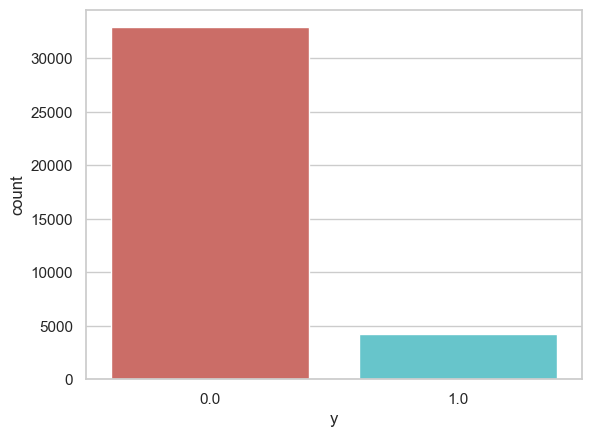

<Figure size 640x480 with 0 Axes>

In [9]:
sns.countplot(x='y',data=data,palette='hls')
plt.show()
plt.savefig('count_plot')

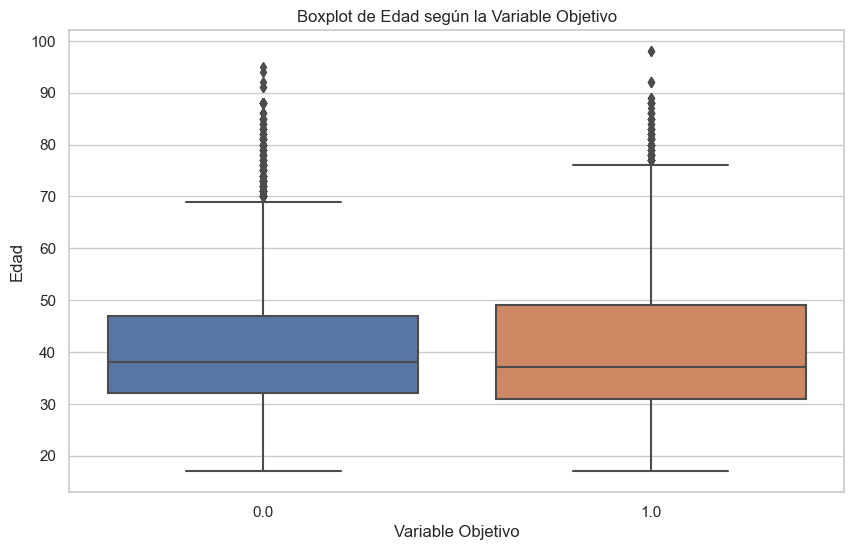

In [10]:
plt.figure(figsize=(10, 6))  # Tamaño de la figura
sns.boxplot(x='y', y='age', data=data)
plt.title('Boxplot de Edad según la Variable Objetivo')
plt.xlabel('Variable Objetivo')
plt.ylabel('Edad')
plt.show()


In [25]:
pd.crosstab(data.age,data.y)

y,0.0,1.0
age,,
17,2,1
18,16,11
19,20,17
20,37,19
21,66,26
...,...,...
91,2,0
92,1,3
94,1,0


In [11]:
pd.crosstab(data.job,data.y)

y,0.0,1.0
job,,
admin.,8148,1231
blue-collar,7778,589
entrepreneur,1194,115
housemaid,861,91
management,2335,296
retired,1171,387
self-employed,1136,128
services,3250,291
student,534,249


** Observacion **
1. Edad promedio de las personas que depositaron más alta que las que no lo hicieron
2. Las personas que realizaron la conversión participaron durante más tiempo durante la llamada.
3. Las personas que realizaron la conversión estuvieron expuestas a menos campañas que las que no lo hicieron.


Text(0, 0.5, 'Frecuencia de compra')

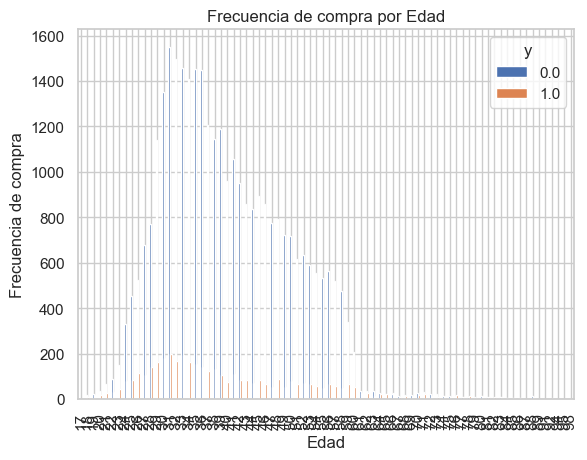

In [27]:
pd.crosstab(data.age,data.y).plot(kind='bar')
plt.title('Frecuencia de compra por Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia de compra')
#plt.savefig('compra_por_cargo')

### Visualizacion 

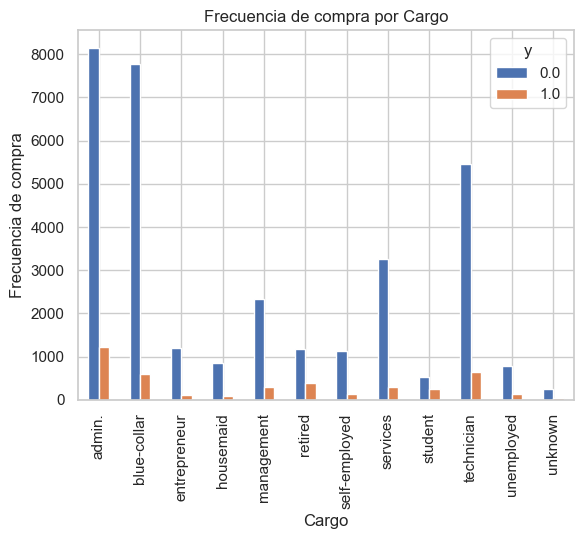

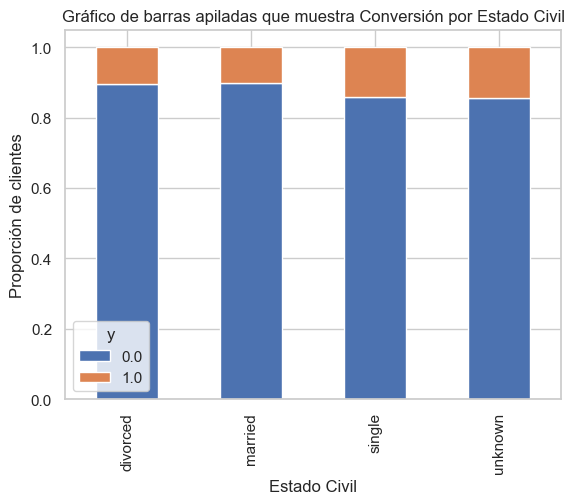

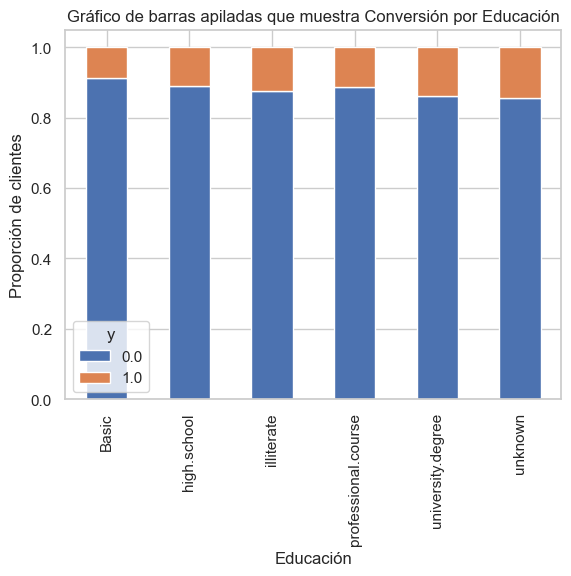

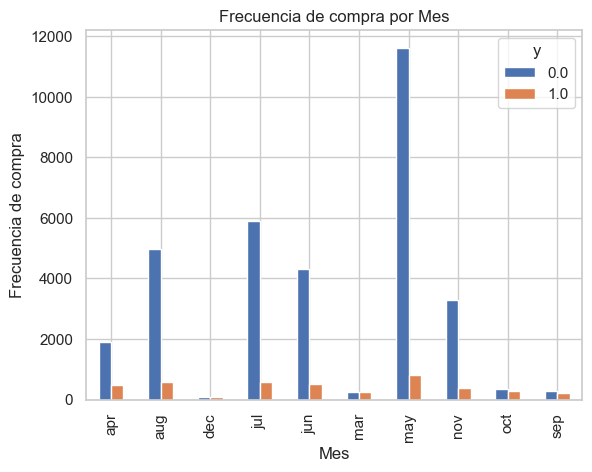

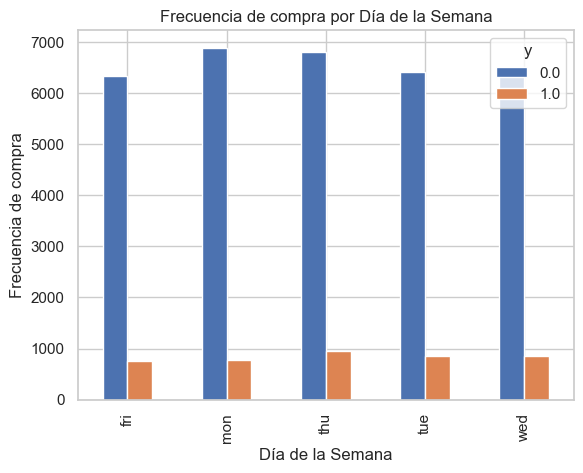

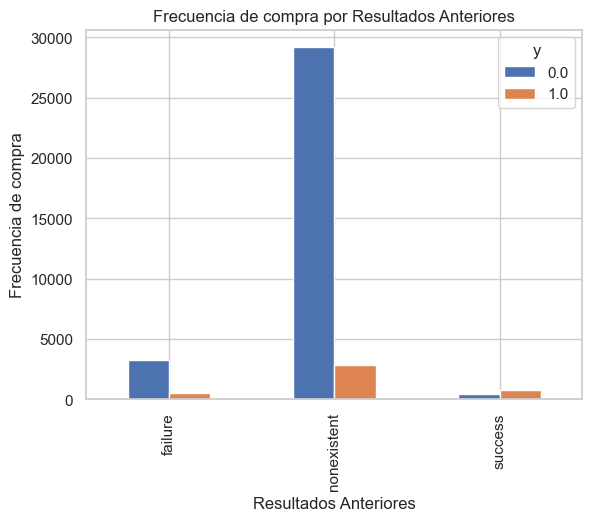

In [12]:

pd.crosstab(data.job,data.y).plot(kind='bar')
plt.title('Frecuencia de compra por Cargo')
plt.xlabel('Cargo')
plt.ylabel('Frecuencia de compra')
plt.savefig('compra_por_cargo')


table = pd.crosstab(data.marital,data.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True)
plt.title('Gráfico de barras apiladas que muestra Conversión por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Proporción de clientes')
plt.savefig('conversion_por_estado_civil')

table = pd.crosstab(data.education,data.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True)
plt.title('Gráfico de barras apiladas que muestra Conversión por Educación')
plt.xlabel('Educación')
plt.ylabel('Proporción de clientes')
plt.savefig('conversion_por_educacion')

pd.crosstab(data.month,data.y).plot(kind='bar')
plt.title('Frecuencia de compra por Mes')
plt.xlabel('Mes')
plt.ylabel('Frecuencia de compra')
plt.savefig('compra_por_mes')


pd.crosstab(data.day_of_week,data.y).plot(kind='bar')
plt.title('Frecuencia de compra por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Frecuencia de compra')
plt.savefig('compra_por_dia_semana')

pd.crosstab(data.poutcome,data.y).plot(kind='bar')
plt.title('Frecuencia de compra por Resultados Anteriores')
plt.xlabel('Resultados Anteriores')
plt.ylabel('Frecuencia de compra')
plt.savefig('compra_por_resultados_anteriores')



###Creando variables bobas


In [13]:
categorical_variable_cols = ['job','marital','education','default','housing','loan','contact','month','day_of_week','poutcome']

for var in categorical_variable_cols:
    categ_list = 'var_' + var
    categ_list = pd.get_dummies(data[var],prefix = var)
    data1=data.join(categ_list)
    data = data1

data_vars = data.columns.values.tolist()
to_keep=[i for i in data_vars if i not in categorical_variable_cols]

In [14]:
data_final = data[to_keep]
data_final.columns.values

array(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student',
       'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_Basic', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_no',
       'default_unknown', 'default_yes', 'housing_no', 'housing_unknown',
       'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes',
       'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug',
       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri',

** Setting the X & Y values **

In [15]:
data_final_vars = data_final.columns.values.tolist()
y=['y']
X = [i for i in data_final_vars if i not in y]

In [17]:
X_train,X_test,y_train,y_test = train_test_split(data_final[X],data_final[y], test_size = 0.3, random_state=0)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

logreg = LogisticRegression(max_iter=2000)

logreg.fit(X_train, y_train)

h:\Anaconda\envs\IA\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=2000)

In [21]:

## Calculating the accuracy
print(logreg.coef_)

[[ 2.54055795e-03  4.63334347e-03 -5.17567994e-02 -1.37494164e-03
  -1.39962343e-02 -4.99954116e-01  3.64244338e-01  1.38713740e-02
   5.09410358e-02 -7.08660762e-03  5.29023069e-02 -1.35349150e-01
  -4.99485511e-02 -4.83762343e-03 -6.72111976e-02  2.71155195e-01
  -1.57335170e-01  3.51932640e-02  1.64359830e-01 -1.40597831e-01
   5.74330039e-02 -2.39292817e-02 -4.46258155e-02 -1.86640572e-02
   8.79751242e-02 -2.28504568e-02 -8.74542183e-02 -1.14285516e-01
   1.33160523e-02  1.31303938e-02  6.50496171e-02  1.12078466e-01
   1.54689020e-01 -1.52359688e-01 -4.94538015e-04 -1.81636553e-02
   1.43734138e-02  5.62503615e-03  3.62572501e-02  1.43734138e-02
  -4.87958692e-02  1.76957034e-01 -1.75122240e-01 -2.48595733e-01
   2.85350188e-01  3.25010314e-02  2.57703190e-01  3.13833243e-01
   9.76810097e-01 -8.55919396e-01 -5.01250855e-01 -3.84173764e-02
  -2.20179594e-01 -7.68906895e-02 -1.64315086e-01  2.16551056e-02
   5.56416455e-02  1.65743819e-01 -3.29677602e-01  1.83186461e-01
   1.48325

In [22]:
y_pred = logreg.predict(X_test)

print('ACC en el test: {:2f}'.format(logreg.score(X_test,y_test)))

ACC en el test: 0.912504


. 
  
  
### (Confusion Matrix)  


In [23]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[9641  258]
 [ 716  517]]
